<a href="https://colab.research.google.com/github/RahulS77/7PAM2002-0509-2024-Final-Project-AQI/blob/master/7PAM2002_0509_2024_Rahul_Shah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Set plot style and ensure inline plotting in Colab
%matplotlib inline
print(plt.style.available) # Print available styles
# plt.style.use('seaborn') # Commented out the problematic line

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


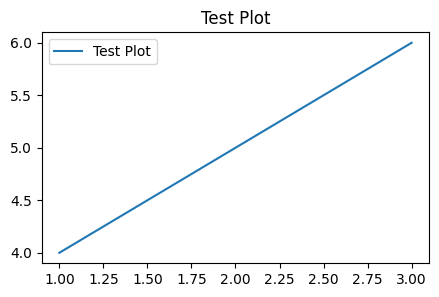

Test plot displayed. If not visible, check Colab rendering.


In [6]:
# Test plot to ensure Matplotlib works
plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3], [4, 5, 6], label='Test Plot')
plt.title('Test Plot')
plt.legend()
plt.show()
print("Test plot displayed. If not visible, check Colab rendering.")

In [7]:
# Define parameter names and file names
data_files = {
    "pm25": "la_pm25_2014_2024.csv",
    "pm10": "la_pm10_2014_2024.csv",
    "ozone": "la_ozone_2014_2024.csv",
    "temperature": "la_temperature_2014_2024.csv",
    "wind_speed": "la_wind_speed_2014_2024.csv",
    "wind_direction": "la_wind_direction_2014_2024.csv",
    "rh": "la_rh_2014_2024.csv"
}

In [8]:
# GitHub repository raw URL base
github_base_url = "https://raw.githubusercontent.com/RahulS77/masters-final-project-aqi/master/raw_data/"

In [9]:
# Simplified function to load and preprocess CSV from GitHub
def load_and_preprocess_csv(param_name, github_url):
    try:
        print(f"\nLoading {param_name} from {github_url}...")
        df = pd.read_csv(github_url, low_memory=False)
        print(f"Shape of {param_name}: {df.shape}")
        print(f"Columns in {param_name}: {list(df.columns)}")
        print(f"Sample rows of {param_name}:\n{df.head(2)}")

        # Check for 'aqi' column
        print(f"'aqi' column in {param_name}: {'aqi' in df.columns}")

        # Select relevant columns
        cols = ['date_local', 'arithmetic_mean']
        if param_name in ['pm25', 'pm10', 'ozone'] and 'aqi' in df.columns:
            cols.append('aqi')
        print(f"Selected columns for {param_name}: {cols}")
        df = df[cols]

        # Convert date_local to datetime and check validity
        df['date_local'] = pd.to_datetime(df['date_local'], errors='coerce')
        invalid_dates = df['date_local'].isna().sum()
        if invalid_dates > 0:
            print(f"Warning: {invalid_dates} invalid dates in {param_name}. Dropping rows with invalid dates.")
        df = df.dropna(subset=['date_local'])
        print(f"Shape after date conversion for {param_name}: {df.shape}")

        # Aggregate to daily (mean)
        df = df.groupby('date_local').mean().reset_index()
        print(f"Shape after daily aggregation for {param_name}: {df.shape}")

        # Rename columns
        df = df.rename(columns={'arithmetic_mean': f'{param_name}_mean'})
        if param_name in ['pm25', 'pm10', 'ozone'] and 'aqi' in df.columns:
            df = df.rename(columns={'aqi': f'{param_name}_aqi'})
        print(f"Final columns for {param_name}: {list(df.columns)}")

        return df
    except Exception as e:
        print(f"Error processing {param_name}: {e}")
        return None


In [10]:
# Load all CSVs from GitHub (simplified)
dfs = []
for param_name, file_name in data_files.items():
    github_url = github_base_url + file_name
    df = load_and_preprocess_csv(param_name, github_url)
    if df is not None and not df.empty:
        dfs.append(df)


Loading pm25 from https://raw.githubusercontent.com/RahulS77/masters-final-project-aqi/master/raw_data/la_pm25_2014_2024.csv...
Shape of pm25: (258894, 32)
Columns in pm25: ['state_code', 'county_code', 'site_number', 'parameter_code', 'poc', 'latitude', 'longitude', 'datum', 'parameter', 'sample_duration_code', 'sample_duration', 'pollutant_standard', 'date_local', 'units_of_measure', 'event_type', 'observation_count', 'observation_percent', 'validity_indicator', 'arithmetic_mean', 'first_max_value', 'first_max_hour', 'aqi', 'method_code', 'method', 'local_site_name', 'site_address', 'state', 'county', 'city', 'cbsa_code', 'cbsa', 'date_of_last_change']
Sample rows of pm25:
   state_code  county_code  site_number  parameter_code  poc  latitude  \
0           6           37            2           88101    1   34.1365   
1           6           37            2           88101    1   34.1365   

   longitude  datum                 parameter sample_duration_code  ...  \
0 -117.92391  WGS

In [11]:
# Check if any DataFrames were loaded
if not dfs:
    raise ValueError("No DataFrames were loaded successfully. Check GitHub URLs or data availability.")

In [12]:
# Merge all DataFrames on date_local
combined_df = dfs[0]
for df in dfs[1:]:
    combined_df = combined_df.merge(df, on='date_local', how='outer')
combined_df = combined_df.set_index('date_local').sort_index()
print(f"\nShape of combined_df: {combined_df.shape}")
print(f"Columns in combined_df: {list(combined_df.columns)}")
print(f"First few rows of combined_df:\n{combined_df.head(5)}")
print(f"pm25_aqi in combined_df: {'pm25_aqi' in combined_df.columns}")
if 'pm25_aqi' in combined_df.columns:
    print(f"pm25_aqi head:\n{combined_df['pm25_aqi'].head(5)}")


Shape of combined_df: (4018, 10)
Columns in combined_df: ['pm25_mean', 'pm25_aqi', 'pm10_mean', 'pm10_aqi', 'ozone_mean', 'ozone_aqi', 'temperature_mean', 'wind_speed_mean', 'wind_direction_mean', 'rh_mean']
First few rows of combined_df:
            pm25_mean    pm25_aqi  pm10_mean   pm10_aqi  ozone_mean  \
date_local                                                            
2014-01-01  57.050000  148.250000  39.131944  34.000000    0.013838   
2014-01-02  14.612500   58.375000  22.262500  20.333333    0.011210   
2014-01-03  22.366667   75.666667  29.888889  27.333333    0.006951   
2014-01-04  33.275000   97.000000  29.729167  27.333333    0.012797   
2014-01-05  17.755556   65.222222  30.990385  30.000000    0.018526   

            ozone_aqi  temperature_mean  wind_speed_mean  wind_direction_mean  \
date_local                                                                      
2014-01-01  24.307692         56.055345         3.779167           110.083333   
2014-01-02  20.2307

In [13]:
# Handle missing values
combined_df = combined_df.interpolate(method='time').fillna(method='ffill').fillna(method='bfill')
print(f"Any NaNs in combined_df after interpolation: {combined_df.isna().sum().sum()}")

Any NaNs in combined_df after interpolation: 0


Available columns for plotting: ['pm25_aqi', 'pm10_aqi', 'ozone_aqi', 'temperature_mean', 'rh_mean']


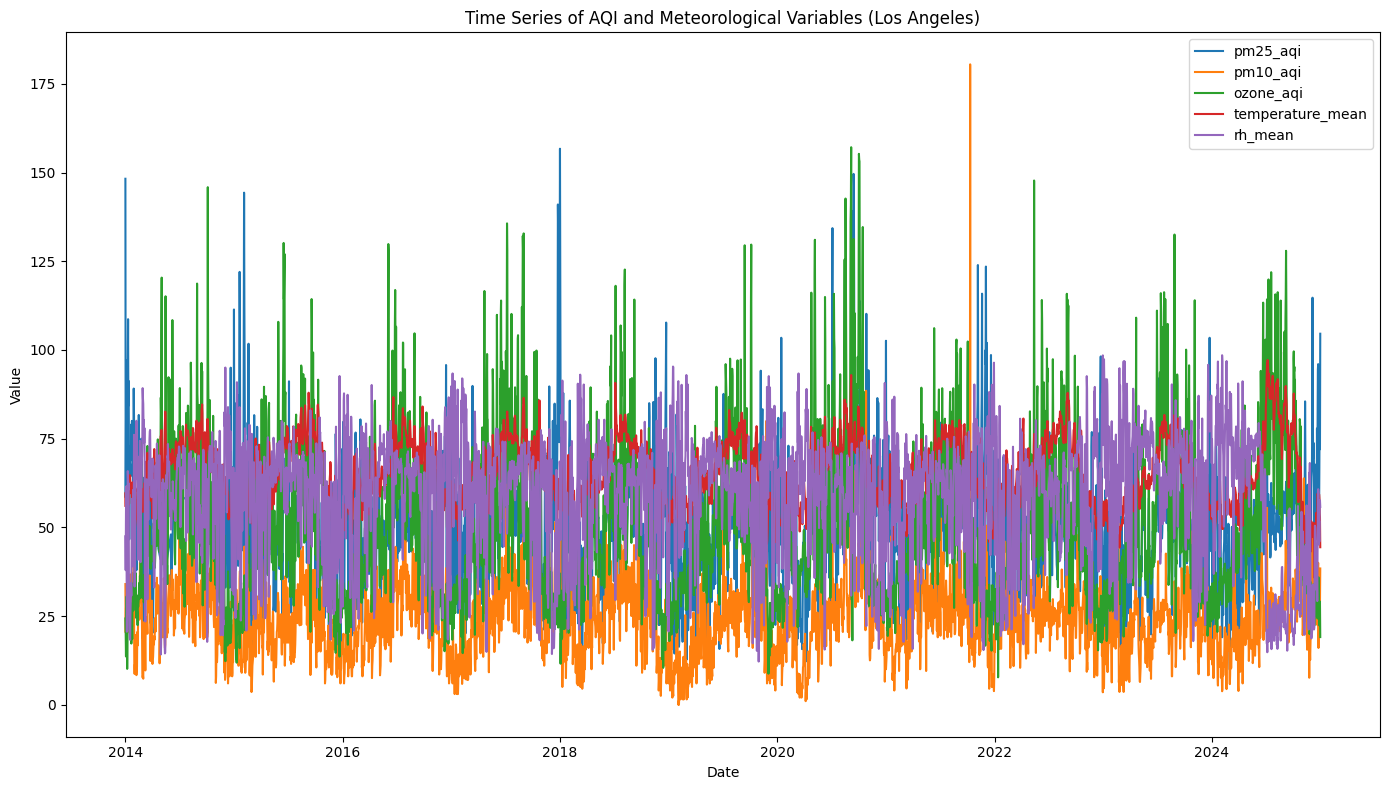

Time series plot displayed and saved.


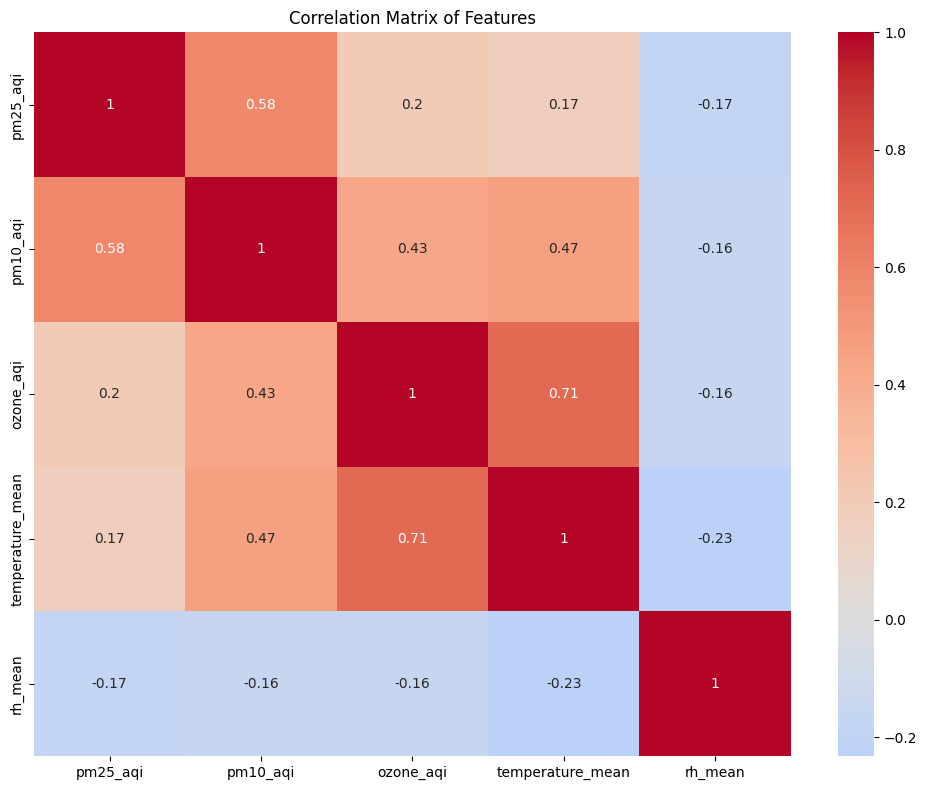

Correlation heatmap displayed and saved.


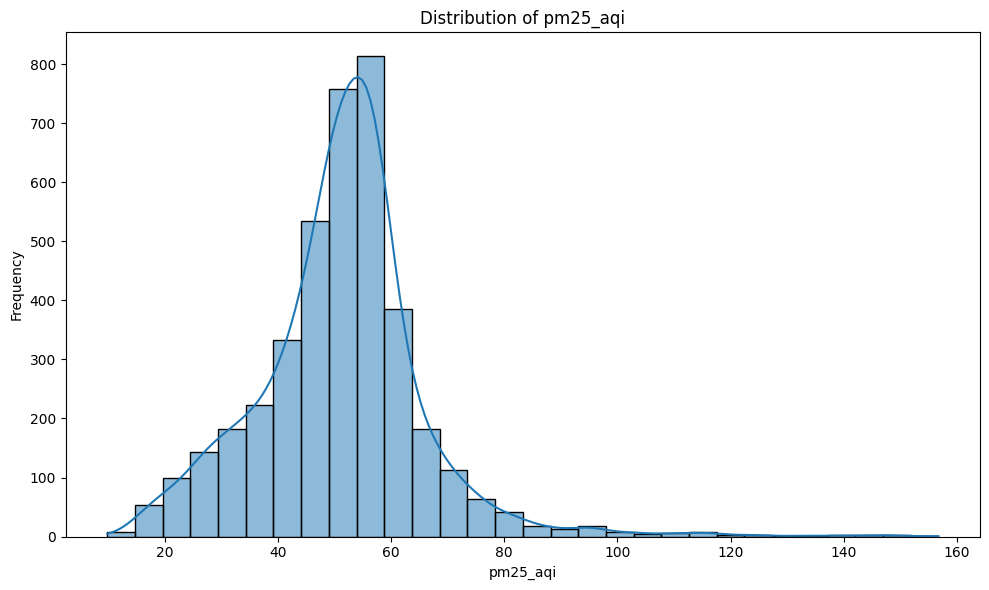

pm25_aqi distribution plot displayed and saved.


In [14]:
# --- Exploratory Data Analysis (EDA) ---
# Select columns for plotting (prioritize AQI, fallback to mean)
plot_columns = ['pm25_aqi', 'pm10_aqi', 'ozone_aqi', 'temperature_mean', 'rh_mean']
if 'pm25_aqi' not in combined_df.columns and 'pm25_mean' in combined_df.columns:
    plot_columns[0] = 'pm25_mean'  # Fallback to pm25_mean
available_columns = [col for col in plot_columns if col in combined_df.columns and not combined_df[col].isna().all()]
print(f"Available columns for plotting: {available_columns}")

if not available_columns:
    print("Warning: No columns available for EDA plots. Skipping EDA plotting.")
else:
    # 1. Time Series Plot
    plt.figure(figsize=(14, 8))
    for col in available_columns:
        plt.plot(combined_df.index, combined_df[col], label=col)
    plt.title('Time Series of AQI and Meteorological Variables (Los Angeles)')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.tight_layout()
    plt.savefig('/content/eda_time_series.png')
    plt.show()
    print("Time series plot displayed and saved.")

    # 2. Correlation Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(combined_df[available_columns].corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Features')
    plt.tight_layout()
    plt.savefig('/content/eda_correlation.png')
    plt.show()
    print("Correlation heatmap displayed and saved.")

    # 3. Distribution Plot (PM2.5 AQI or mean)
    target_col = 'pm25_aqi' if 'pm25_aqi' in combined_df.columns else 'pm25_mean'
    if target_col in combined_df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(combined_df[target_col].dropna(), bins=30, kde=True)
        plt.title(f'Distribution of {target_col}')
        plt.xlabel(target_col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig('/content/eda_distribution.png')
        plt.show()
        print(f"{target_col} distribution plot displayed and saved.")
    else:
        print(f"Warning: '{target_col}' column not found. Skipping distribution plot.")

In [15]:
# --- Prepare Data for Modeling ---
# Option to use combined AQI or just pm25_aqi
use_combined_aqi = True  # Set to False for pm25_aqi only
if use_combined_aqi and all(x in combined_df.columns for x in ['pm25_aqi', 'pm10_aqi', 'ozone_aqi']):
    combined_df['combined_aqi'] = (0.4 * combined_df['pm25_aqi'].fillna(0) +
                                  0.3 * combined_df['pm10_aqi'].fillna(0) +
                                  0.3 * combined_df['ozone_aqi'].fillna(0))
    target = 'combined_aqi'
else:
    target = 'pm25_aqi' if 'pm25_aqi' in combined_df.columns else 'pm25_mean'
print(f"Modeling target: {target}")
series = combined_df[target].dropna()
print(f"Length of series: {len(series)}")
print(f"First few values of series:\n{series.head(5)}")

Modeling target: combined_aqi
Length of series: 4018
First few values of series:
date_local
2014-01-01    76.792308
2014-01-02    35.519231
2014-01-03    42.543590
2014-01-04    54.615385
2014-01-05    44.250427
Name: combined_aqi, dtype: float64


In [16]:
# Train-test split (80-20)
train_size = int(len(series) * 0.8)
if train_size < 10:
    raise ValueError(f"Train size ({train_size}) is too small for modeling. Check data availability.")
train, test = series[:train_size], series[train_size:]
print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 3214, Test size: 804


In [17]:
# --- ARIMA Model ---
# Manual ARIMA parameters to avoid pmdarima issue
order = (2, 1, 2)  # Increased complexity to address underfitting
seasonal_order = (0, 0, 0, 0)
print(f"ARIMA params: order={order}, seasonal_order={seasonal_order}")
arima_model = SARIMAX(train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
arima_results = arima_model.fit(disp=False)
arima_forecast = arima_results.forecast(steps=len(test))
arima_forecast_7day = arima_results.forecast(steps=7)
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
print(f"ARIMA MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f}")

ARIMA params: order=(2, 1, 2), seasonal_order=(0, 0, 0, 0)
ARIMA MAE: 9.92, RMSE: 12.19


In [18]:
# --- Random Forest Model ---
features = [col for col in combined_df.columns if '_mean' in col or '_aqi' in col]
if not features:
    print("Warning: No features available for Random Forest. Skipping RF modeling.")
    rf_mae = rf_rmse = rf_forecast = rf_forecast_7day = None
else:
    X = combined_df[features].dropna()
    y = combined_df[target].loc[X.index]
    print(f"Random Forest features: {features}")
    print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)  # Regularized to reduce overfitting
    rf_model.fit(X_train, y_train)
    rf_forecast = rf_model.predict(X_test)
    rf_forecast_7day = rf_model.predict(X_scaled[-7:])
    rf_mae = mean_absolute_error(y_test, rf_forecast)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_forecast))
    print(f"Random Forest MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}")

Random Forest features: ['pm25_mean', 'pm25_aqi', 'pm10_mean', 'pm10_aqi', 'ozone_mean', 'ozone_aqi', 'temperature_mean', 'wind_speed_mean', 'wind_direction_mean', 'rh_mean', 'combined_aqi']
Shape of X: (4018, 11), Shape of y: (4018,)
Random Forest MAE: 0.02, RMSE: 0.12


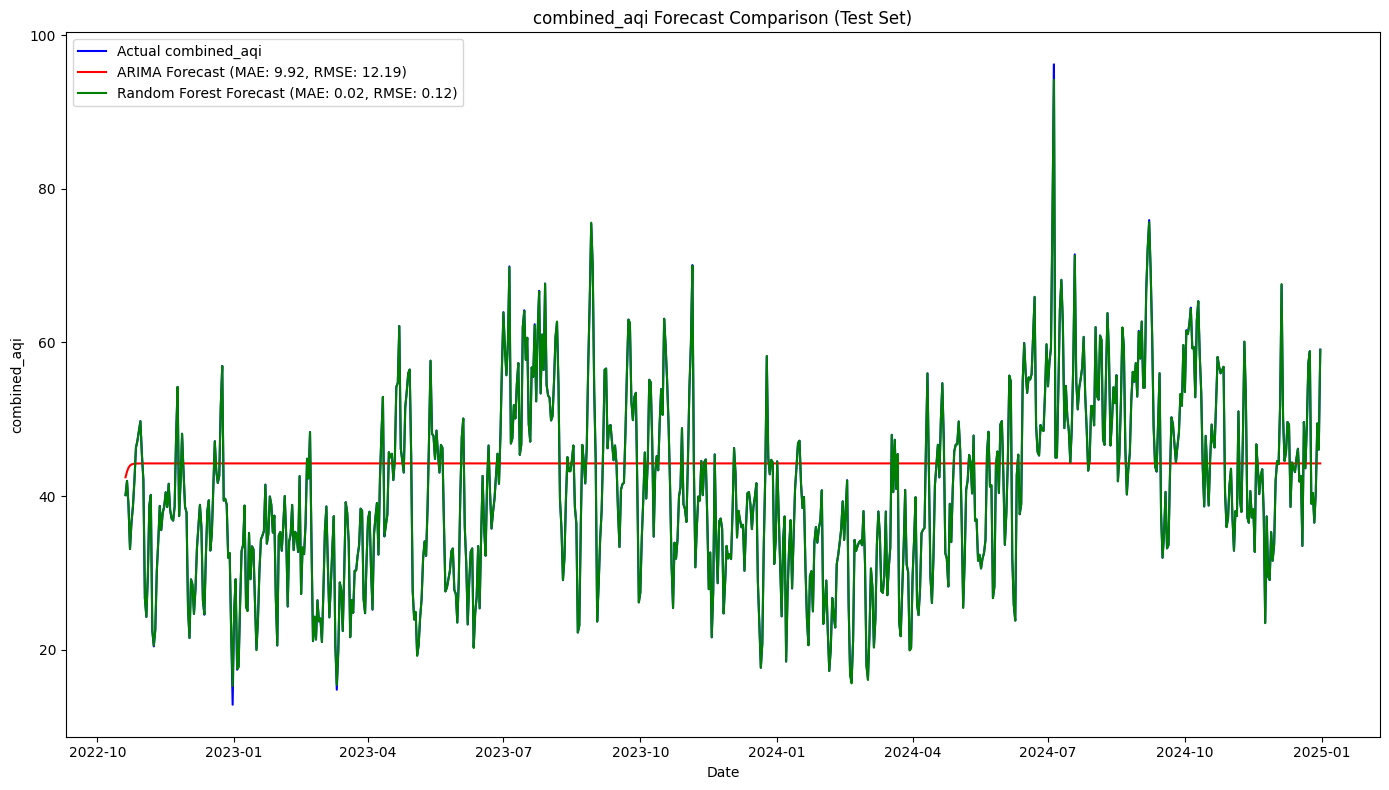

Forecast comparison plot displayed and saved.


In [19]:
# --- Visualization with Accuracy Metrics ---
# 1. Forecast Comparison Plot
plt.figure(figsize=(14, 8))
plt.plot(test.index, test, label=f'Actual {target}', color='blue')
plt.plot(test.index, arima_forecast, label=f'ARIMA Forecast (MAE: {arima_mae:.2f}, RMSE: {arima_rmse:.2f})', color='red')
if rf_forecast is not None:
    plt.plot(test.index, rf_forecast, label=f'Random Forest Forecast (MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f})', color='green')
plt.title(f'{target} Forecast Comparison (Test Set)')
plt.xlabel('Date')
plt.ylabel(target)
plt.legend()
plt.tight_layout()
plt.savefig('/content/forecast_comparison.png')
plt.show()
print("Forecast comparison plot displayed and saved.")

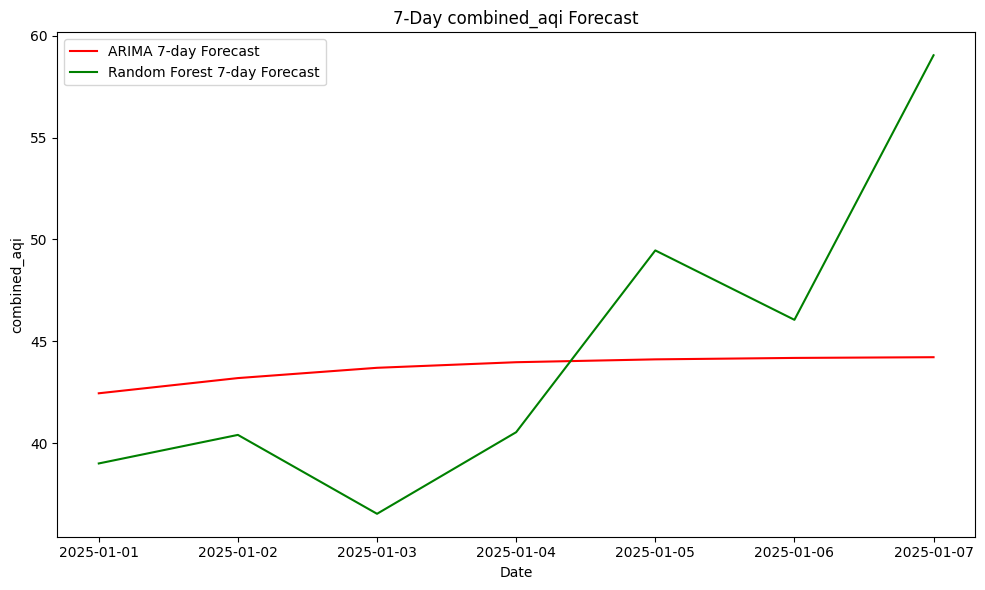

7-day forecast plot displayed and saved.


In [20]:
# 2. 7-Day Forecast Plot
future_dates = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=7)
plt.figure(figsize=(10, 6))
plt.plot(future_dates, arima_forecast_7day, label='ARIMA 7-day Forecast', color='red')
if rf_forecast_7day is not None:
    plt.plot(future_dates, rf_forecast_7day, label='Random Forest 7-day Forecast', color='green')
plt.title(f'7-Day {target} Forecast')
plt.xlabel('Date')
plt.ylabel(target)
plt.legend()
plt.tight_layout()
plt.savefig('/content/7day_forecast.png')
plt.show()
print("7-day forecast plot displayed and saved.")

<Figure size 800x600 with 0 Axes>

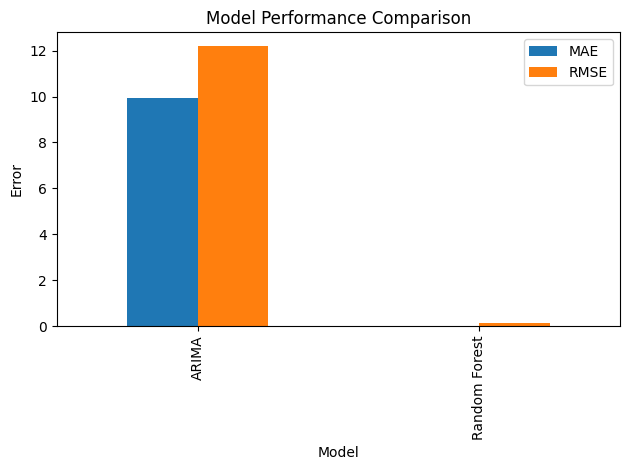

Metrics bar plot displayed and saved.


In [21]:
# 3. Accuracy Metrics Bar Plot
metrics = pd.DataFrame({
    'Model': ['ARIMA'],
    'MAE': [arima_mae],
    'RMSE': [arima_rmse]
})
if rf_mae is not None:
    metrics = pd.concat([metrics, pd.DataFrame({'Model': ['Random Forest'], 'MAE': [rf_mae], 'RMSE': [rf_rmse]})], ignore_index=True)
plt.figure(figsize=(8, 6))
metrics.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar')
plt.title('Model Performance Comparison')
plt.ylabel('Error')
plt.tight_layout()
plt.savefig('/content/model_metrics.png')
plt.show()
print("Metrics bar plot displayed and saved.")

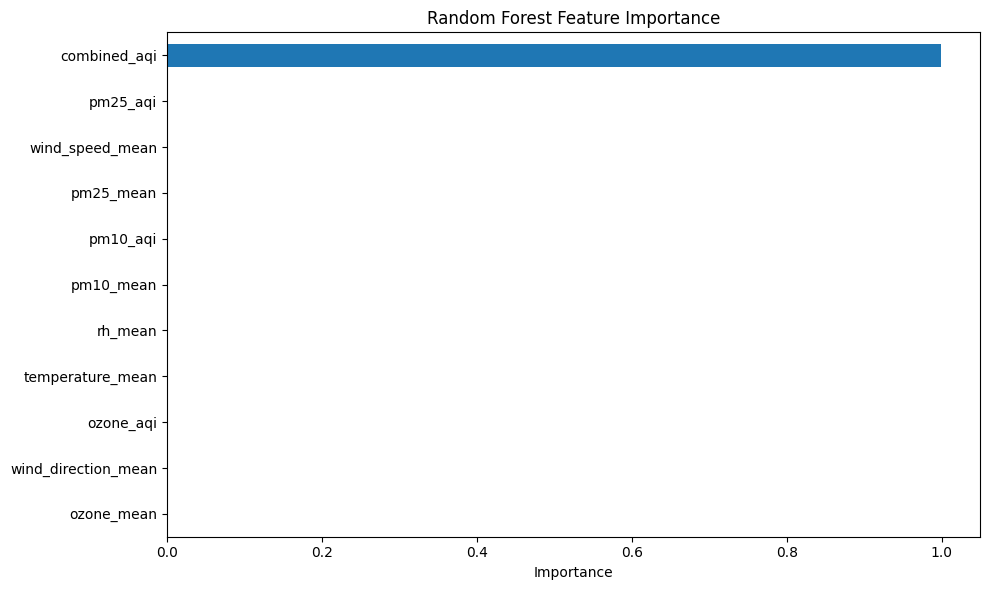

Feature importance plot displayed and saved.


In [22]:
# 4. Random Forest Feature Importance Plot
if rf_forecast is not None:
    plt.figure(figsize=(10, 6))
    importances = pd.Series(rf_model.feature_importances_, index=features)
    importances.sort_values().plot(kind='barh')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('/content/feature_importance.png')
    plt.show()
    print("Feature importance plot displayed and saved.")
else:
    print("Feature importance plot skipped due to missing Random Forest model.")

In [23]:
# --- Save Results ---
results = pd.DataFrame({
    'Date': future_dates,
    'ARIMA_Forecast': arima_forecast_7day
})
if rf_forecast_7day is not None:
    results['Random_Forest_Forecast'] = rf_forecast_7day
results.to_csv('/content/aqi_forecast_results.csv', index=False)
metrics.to_csv('/content/model_metrics.csv', index=False)
print("Results saved to 'aqi_forecast_results.csv' and 'model_metrics.csv'")

Results saved to 'aqi_forecast_results.csv' and 'model_metrics.csv'
